In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [43]:
df = pd.read_csv('nba_stats.csv')
df_dic = pd.read_csv('dicionario_dataset_nba.csv')
df.head(3)

,year,name,playerId,playerSlug,positionId,teamId,status,gamesPlayed,avgMinutes,avgFouls,flagrantFouls,technicalFouls,ejections,doubleDouble,tripleDouble,minutes,rebounds,fouls,avgRebounds,avgPoints,avgFieldGoalsMade,avgFieldGoalsAttempted,fieldGoalPct,avgThreePointFieldGoalsMade,avgThreePointFieldGoalsAttempted,threePointFieldGoalPct,avgFreeThrowsMade,avgFreeThrowsAttempted,freeThrowPct,avgAssists,avgTurnovers,points,fieldGoalsMade,fieldGoalsAttempted,threePointFieldGoalsMade,threePointFieldGoalsAttempted,freeThrowsMade,freeThrowsAttempted,assists,turnovers,avgSteals,avgBlocks,steals,blocks,position,birthdate,college,draftinfo,birthplace,team,htwt,experience,rankingSalary,salary
0,1999,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,41.458332,2.041667,0.0,5.0,0.0,4.0,0.0,1990.0,236.0,98.0,4.916666,26.750000,9.062500,22.000000,41.193001,1.208333,4.145834,29.145730,7.416666,9.875000,75.105003,4.645834,3.479167,1284.0,435.0,1056.0,58.0,199.0,356.0,474.0,223.0,167.0,2.291667,0.145833,110.0,7.0,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,15,"$9,000,000"
1,2000,Allen Iverson,366,allen-iverson,SG,PHI,inactive,70.0,40.757140,2.314286,0.0,12.0,0.0,1.0,0.0,2853.0,267.0,162.0,3.814286,28.414286,10.414286,24.757143,42.066002,1.271429,3.728571,34.099618,6.314286,8.857142,71.290001,4.685714,3.285714,1989.0,729.0,1733.0,89.0,261.0,442.0,620.0,328.0,230.0,2.057143,0.071429,144.0,5.0,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,27,"$10,125,000"
2,2001,Allen Iverson,366,allen-iverson,SG,PHI,inactive,71.0,41.957745,2.070423,0.0,18.0,0.0,4.0,0.0,2979.0,273.0,147.0,3.845070,31.084507,10.732394,25.535212,42.029999,1.380282,4.309859,32.026145,8.239436,10.126760,81.362999,4.577465,3.338028,2207.0,762.0,1813.0,98.0,306.0,585.0,719.0,325.0,237.0,2.507042,0.281690,178.0,20.0,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,17,"$11,250,000"


In [44]:
## conversão de string da coluna 'salary' para float
df['salary'] = (df['salary'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(np.float64))
df_=df.copy()

In [45]:
## conversão da data de nascimento para idade
#df_['birthdate'].unique()
df_['birthdate_clean'] = df_['birthdate'].str.replace(r'\s*\(.*\)', '', regex=True)
#df_['birthdate_clean'].unique()
df_['birthdate_clean'] = pd.to_datetime(df_['birthdate_clean'], dayfirst=False)
#df_['birthdate_clean'].unique()
df_['age'] = (pd.to_datetime('today') - df_['birthdate_clean']).dt.days // 365.25

In [46]:
df_ = df_.drop(['name','positionId','playerId','playerSlug','college','birthplace','draftinfo','htwt','rankingSalary','team','birthdate','birthdate_clean','experience'],axis=1)


In [50]:
df_['status'].unique()
df_["status"] = df_["status"].map({"active": 1, "inactive": 0})


In [51]:
df_.head(3)

,year,teamId,status,gamesPlayed,avgMinutes,avgFouls,flagrantFouls,technicalFouls,ejections,doubleDouble,tripleDouble,minutes,rebounds,fouls,avgRebounds,avgPoints,avgFieldGoalsMade,avgFieldGoalsAttempted,fieldGoalPct,avgThreePointFieldGoalsMade,avgThreePointFieldGoalsAttempted,threePointFieldGoalPct,avgFreeThrowsMade,avgFreeThrowsAttempted,freeThrowPct,avgAssists,avgTurnovers,points,fieldGoalsMade,fieldGoalsAttempted,threePointFieldGoalsMade,threePointFieldGoalsAttempted,freeThrowsMade,freeThrowsAttempted,assists,turnovers,avgSteals,avgBlocks,steals,blocks,position,salary,age
0,1999,PHI,0,48.0,41.458332,2.041667,0.0,5.0,0.0,4.0,0.0,1990.0,236.0,98.0,4.916666,26.750000,9.062500,22.000000,41.193001,1.208333,4.145834,29.145730,7.416666,9.875000,75.105003,4.645834,3.479167,1284.0,435.0,1056.0,58.0,199.0,356.0,474.0,223.0,167.0,2.291667,0.145833,110.0,7.0,Shooting Guard,9000000.0,50.0
1,2000,PHI,0,70.0,40.757140,2.314286,0.0,12.0,0.0,1.0,0.0,2853.0,267.0,162.0,3.814286,28.414286,10.414286,24.757143,42.066002,1.271429,3.728571,34.099618,6.314286,8.857142,71.290001,4.685714,3.285714,1989.0,729.0,1733.0,89.0,261.0,442.0,620.0,328.0,230.0,2.057143,0.071429,144.0,5.0,Shooting Guard,10125000.0,50.0
2,2001,PHI,0,71.0,41.957745,2.070423,0.0,18.0,0.0,4.0,0.0,2979.0,273.0,147.0,3.845070,31.084507,10.732394,25.535212,42.029999,1.380282,4.309859,32.026145,8.239436,10.126760,81.362999,4.577465,3.338028,2207.0,762.0,1813.0,98.0,306.0,585.0,719.0,325.0,237.0,2.507042,0.281690,178.0,20.0,Shooting Guard,11250000.0,50.0


In [53]:
df_.to_csv('df_final.csv')

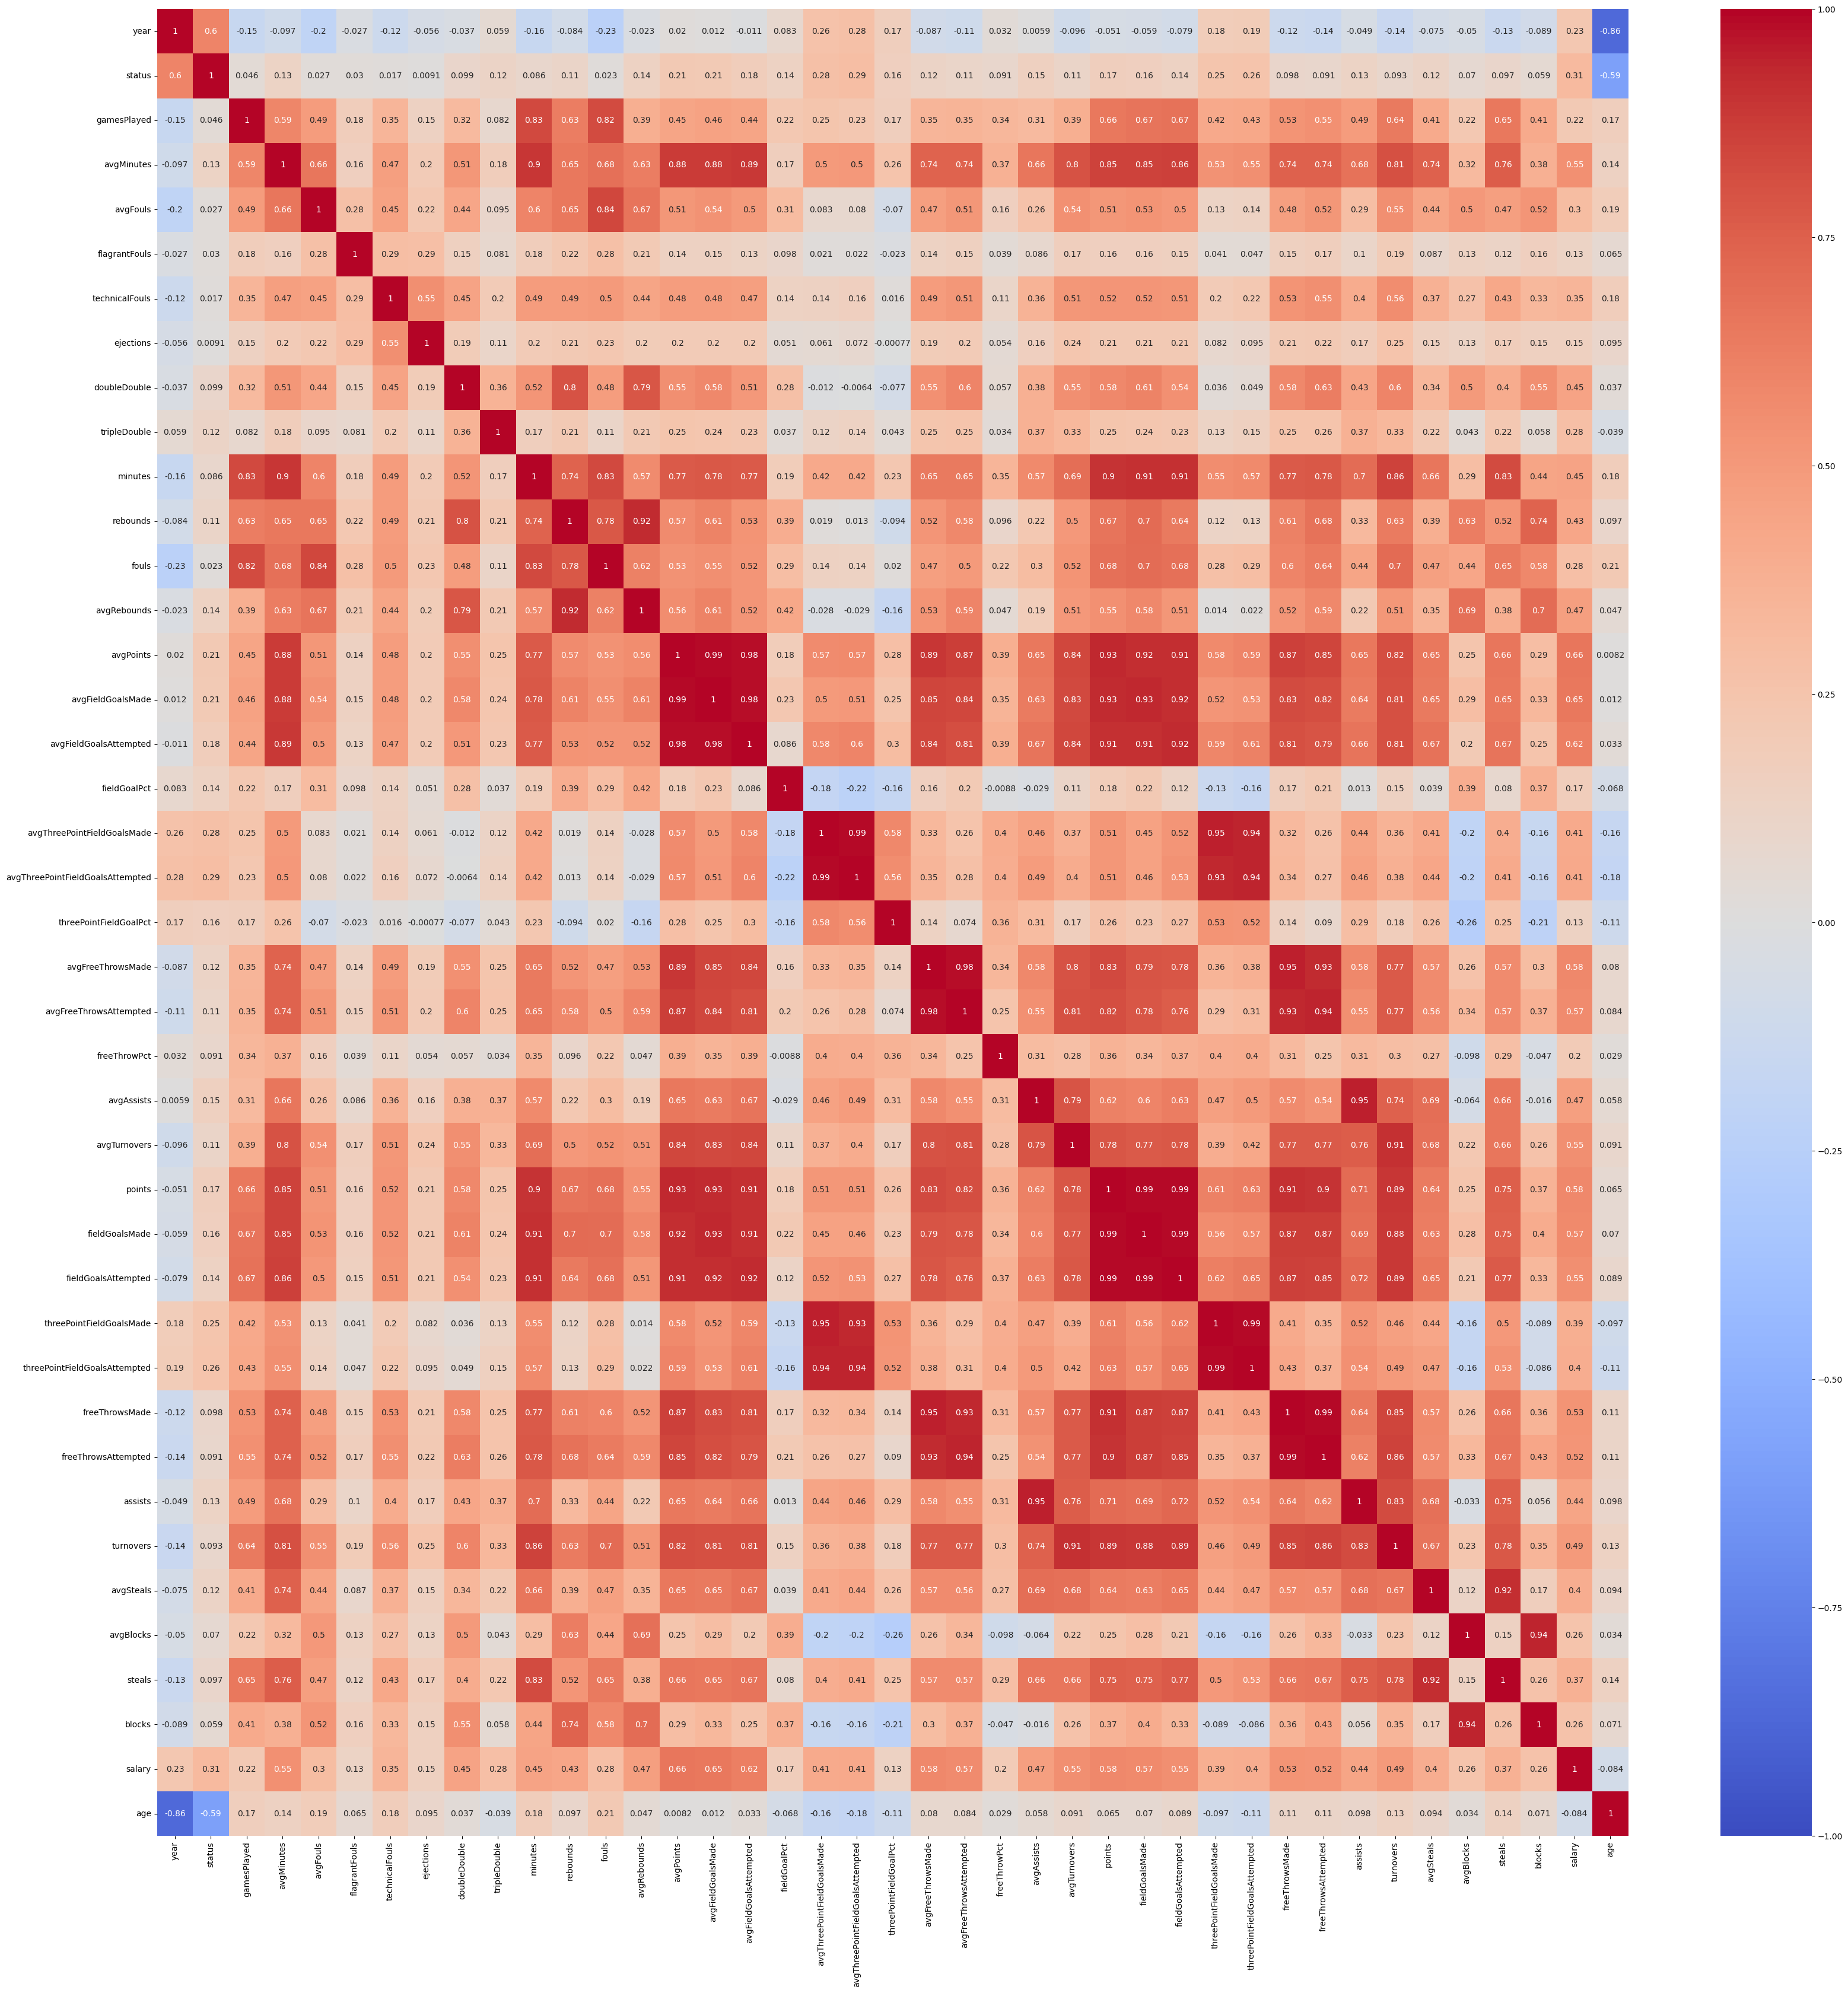

In [54]:

df_num = df_.select_dtypes(include=["number"])
correlacao = df_num.corr()

plt.figure(figsize=(40,40))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()


## Definição amostragem

In [ ]:
# Ajuste aqui se o alvo não for 'salary'
target_col = "salary"

# Garante que df_ existe
assert target_col in df_.columns, "Coluna alvo 'salary' não encontrada em df_"

X = df_.drop(columns=[target_col])
y = df_[target_col].copy()

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=43,  # (42 + 1 como você usou)
    shuffle=True
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape




## Pipelines de Transformação

In [66]:
# Detecta dtypes após o split (importante!)
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# Imputers e scalers
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Compatibilidade de versão do OneHotEncoder
if sklearn.__version__ >= "1.2":
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
else:
    ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", ohe)
])

full_pipeline = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Fit no TREINO e transform nos dois
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared  = full_pipeline.transform(X_test)

X_train_prepared.shape, X_test_prepared.shape


(8162, 82)

In [ ]:

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_prepared, y_prepared) # X without 1's,y

print(lin_reg.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [69]:
housing2 = df_.drop("salary", axis=1)          # DataFrame
housing_labels = df_["salary"].copy()         # Series

housing_prepared = full_pipeline.fit_transform(housing2) 

some_data = housing2.iloc[:5]
some_data_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

some_data_predicted = lin_reg.predict(some_data_prepared)

print(some_data_labels) # y
print(some_data_predicted) # y_hat

0     9000000.0
1    10125000.0
2    11250000.0
3    12375000.0
4    13500000.0
Name: salary, dtype: float64
[14703792.37792331 11094999.88573581 14147630.3561948  15955980.74828464
 10023404.80809909]


In [70]:
from sklearn.metrics import mean_squared_error
# from sklearn.metrics import root_mean_squared_error

housing_predicted = lin_reg.predict(X_prepared)
lin_reg_rmse = np.sqrt(mean_squared_error(y_prepared, housing_predicted)) # y,y_hat

print(lin_reg_rmse) # Underfitting?

4405104.370847838


In [71]:
print("Média salário:", df_["salary"].mean())
print("Mediana salário:", df_["salary"].median())
print("RMSE:", lin_reg_rmse)
print("RMSE / Média salário:", lin_reg_rmse / df_["salary"].mean())

Média salário: 6156346.203013967
Mediana salário: 3500000.0
RMSE: 4405104.370847838
RMSE / Média salário: 0.7155387669217218
